# Neural Networks and Deep Learning (Practical)

**Time box:** 45 minutes. You will not finish. Get as far as you can while narrating.

## Brief

An optical inspection line flags defective parts. `data_source.load_raw_split` gives you the frames and labels that were captured. Nothing else is trustworthy until you have checked it.

Build a binary detector, train it, evaluate it honestly, and choose an operating point.

## Rules

- Every code cell has at least one `NotImplementedError`. Replace all of them.
- Work top to bottom. Later cells call earlier ones.
- Nothing is imported for you beyond the basics. If you want a helper, write it.
- `solution.py` sits next to this notebook. Opening it ends the exercise.
- Say what you are doing and why, before you do it.

## 0 — Setup

In [17]:
from __future__ import annotations

import math
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

_here = Path.cwd()
if not (_here / "data_source.py").exists():
    _here = Path("src/torch_modules/nn_dl_practical").resolve()
sys.path.insert(0, str(_here))

from data_source import load_raw_split

CFG = {"seed": 0, "batch_size": 64}


def seed_everything(seed: int) -> None:
    """Make this notebook as reproducible as you are willing to claim it is."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    if "cuda" == resolve_device():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        torch.use_deterministic_algorithms(True)


def resolve_device() -> torch.device:
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    return torch.device(dev)

seed_everything(CFG["seed"])
device = resolve_device()
print(device)

cpu


## 1 — The data

You have two splits and no documentation.

In [24]:
def inspect_raw(x: np.ndarray, y: np.ndarray) -> dict:
    """Return everything you want to know before writing a line of training code."""
    return {
        "x shape": x.shape, "x mean": x.mean(), "x std": x.std(), "x min": x.min(), "x.max()": x.max(),
        "y shape": y.shape, "y mean": y.mean(), "y std": y.std(), "y min": y.min(), "y.max()": y.max(),
    }


raw = {split: load_raw_split(split) for split in ("train", "val")}

for split, (x, y) in raw.items():
    print(split)
    for key, value in inspect_raw(x, y).items():
        print(f"  {key}: {value}")

train
  x shape: (6000, 1, 28, 28)
  x mean: 2001.23388671875
  x std: 434.3437805175781
  x min: -380.5680236816406
  x.max(): 4633.58740234375
  y shape: (6000,)
  y mean: 0.009999999776482582
  y std: 0.09949875622987747
  y min: 0.0
  y.max(): 1.0
val
  x shape: (1500, 1, 28, 28)
  x mean: 1997.3505756884676
  x std: 430.69955990320057
  x min: -114.35819424034025
  x.max(): 4430.640779326301
  y shape: (1500, 1)
  y mean: 0.01
  y std: 0.09949874371066199
  y min: 0.0
  y.max(): 1.0


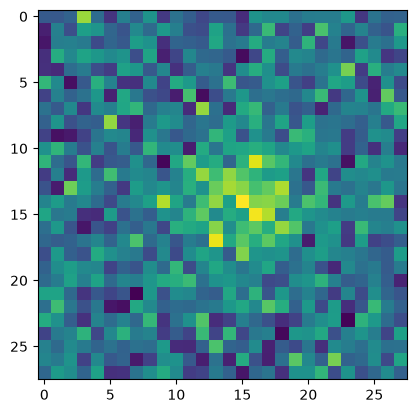

In [36]:
import matplotlib.pyplot as plt
pos_ids = np.where(raw["train"][1]  == 1)[0]
plt.imshow(raw["train"][0][pos_ids[0], 0])

In [40]:
def to_tensors(x: np.ndarray, y: np.ndarray) -> tuple[torch.Tensor, torch.Tensor]:
    """Turn one raw split into tensors you are willing to feed a network."""
    
    return torch.tensor(x), torch.tensor(y)

class BlobDataset(torch.utils.data.Dataset):
    def __init__(self, data, target):
        super().__init__()
        self._data = data
        self._target = target
    
    def __len__(self):
        return len(self._data)
    
    def __getitem__(self, x):
        return self._data[x], self._target[x]

def build_loaders(
    train: tuple[torch.Tensor, torch.Tensor],
    val: tuple[torch.Tensor, torch.Tensor],
    batch_size: int,
    pin_memory: bool = True,
) -> tuple[DataLoader, DataLoader]:

    train_loader = DataLoader(dataset=BlobDataset(data=train[0], target=train[1]), batch_size=batch_size, pin_memory=pin_memory)
    val_loader = DataLoader(dataset=BlobDataset(data=val[0], target=val[1]), batch_size=batch_size, pin_memory=pin_memory)

    return train_loader, val_loader



train_split = to_tensors(*raw["train"])
val_split = to_tensors(*raw["val"])
train_loader, val_loader = build_loaders(train_split, val_split, CFG["batch_size"])

xb, yb = next(iter(train_loader))
print(xb.shape, xb.dtype, yb.shape, yb.dtype)

torch.Size([64, 1, 28, 28]) torch.float32 torch.Size([64]) torch.float32


In [ ]:
def checks_before_trusting_numbers(
    train: tuple[torch.Tensor, torch.Tensor],
    val: tuple[torch.Tensor, torch.Tensor],
) -> dict:
    """The checks you want in place before you believe any metric this notebook prints.

    Return the findings. Fail loudly on anything you consider disqualifying.
    """
    raise NotImplementedError


for key, value in checks_before_trusting_numbers(train_split, val_split).items():
    print(f"{key}: {value}")

## 2 — The model

In [46]:
class TinyDetector(nn.Module):
    """Binary detector over single-channel 28x28 frames.

    ``forward`` returns one number per frame. You decide what that number means;
    the rest of the notebook has to agree with your decision.
    """

    def __init__(self, kind: str = "cnn", width: int = 16, dropout: float = 0.25) -> None:
        super().__init__()
        
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=width, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=width, out_channels=width, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(),
        )
        self.head = nn.Sequential(nn.AdaptiveMaxPool2d(1), nn.Conv2d(in_channels=width, out_channels=1, kernel_size=(1,1)), nn.Flatten())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        
        hidden_1 = self.conv_block_1(x)
        hidden_2 = self.conv_block_2(hidden_1) + hidden_1 # residual connection!
        out = self.head(hidden_2)
        return out


In [47]:
probe = TinyDetector().to(device)

np.prod((3, 4,5))

np.int64(60)

In [49]:
def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    p_count = 0
    for _, parameter in model.named_parameters():
        p_count += np.prod(parameter.shape)
    return p_count

def check_output_contract(model: nn.Module) -> None:
    """Assert the model does what you just claimed, for every input shape a caller may pass."""
    
    x = torch.randn(4, 1, 28, 28)
    pred = model(x)
    assert np.all(pred.shape == (4, 1))


probe = TinyDetector().to(device)
check_output_contract(probe)
print("params:", count_parameters(probe))

params: 2561


## 3 — Loss and one step

Write the loss yourself. `torch.nn.BCELoss`, `nn.BCEWithLogitsLoss` and `F.binary_cross_entropy*` are off limits inside `bce_with_logits`.

In [50]:
def bce_with_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    pos_weight: torch.Tensor | float | None = None,
) -> torch.Tensor:
    """Mean binary cross entropy from raw scores. Scalar tensor, differentiable."""

    # BCE formula: target * log(prob) + (1 - target) * log(1 - prob)
    # Sigmoid: 1 / (1 + exp(-logit))

    # neg_log_prob = torch.log(1 + torch.exp(-logits))
    # with help:
    neg_log_prob = torch.maximum(-logits, 0) + torch.log(1 + torch.exp(-torch.abs(logits)))
    loss_bce = neg_log_prob + (1 - targets) * logits

    if pos_weight is None:
        return loss_bce.mean()

    if isinstance(pos_weight, float) or isinstance(pos_weight, torch.Tensor):
        return ((targets * pos_weight) * loss_bce + (1 - targets) * (1 - pos_weight) * loss_bce).sum()



def verify_loss() -> None:
    """Convince a hostile reviewer that ``bce_with_logits`` is right, including at extremes."""
    # raise NotImplementedError
    pass


verify_loss()
print("loss ok")

loss ok


In [ ]:
# binary search

In [ ]:
def grad_norm(model: nn.Module) -> float:
    


    raise NotImplementedError


def single_step_diagnostics(
    model: nn.Module,
    batch: tuple[torch.Tensor, torch.Tensor],
    optimizer: torch.optim.Optimizer,
) -> dict:
    """Run exactly one optimisation step and return the numbers that prove it did
    what you intended, in the order you intended."""

    model.train()
    optimizer.zero_grad()

    pred =  model(batch[0])
    loss = bce_with_logits(pred, batch[1])

    loss.backward()
    optimizer.step()




seed_everything(CFG["seed"])
step_model = TinyDetector().to(device)
step_opt = torch.optim.SGD(step_model.parameters(), lr=1e-2)

for key, value in single_step_diagnostics(step_model, next(iter(train_loader)), step_opt).items():
    print(f"{key}: {value}")

## 4 — Loops

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn,
) -> float:
    """One pass over ``loader``. Return the mean loss over samples."""
    raise NotImplementedError

In [ ]:
def evaluate(model: nn.Module, loader: DataLoader, loss_fn) -> dict:
    """Return the loss and whatever else you need to compute any metric, at any
    operating point, without touching the model again."""
    raise NotImplementedError

In [ ]:
def mode_sensitivity(model: nn.Module, batch: tuple[torch.Tensor, torch.Tensor]) -> dict:
    """Quantify how much this model's output depends on things other than its
    weights and its input. Return numbers, not adjectives."""
    raise NotImplementedError


for key, value in mode_sensitivity(step_model, next(iter(val_loader))).items():
    print(f"{key}: {value}")

In [ ]:
def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn,
    epochs: int,
) -> dict:
    """Train, evaluate each epoch, print progress, return the history plus whatever
    you would need to reproduce or roll back to the best state."""
    raise NotImplementedError

In [ ]:
def build_training_setup() -> tuple[nn.Module, torch.optim.Optimizer, object, int]:
    """Return (model, optimizer, loss_fn, epochs). Defend every choice out loud."""
    raise NotImplementedError


seed_everything(CFG["seed"])
model, optimizer, loss_fn, epochs = build_training_setup()
history = fit(model, train_loader, val_loader, optimizer, loss_fn, epochs)

## 5 — Is it any good?

In [ ]:
def precision_recall_f1(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[float, float, float]:
    """Binary 0/1 arrays in, (precision, recall, f1) out."""
    raise NotImplementedError


def test_precision_recall_f1() -> None:
    """The cases that would catch a wrong implementation. Include the ugly ones."""
    raise NotImplementedError


test_precision_recall_f1()
print("metrics ok")

In [ ]:
def trivial_baselines(y_true: np.ndarray) -> dict:
    """The numbers a model has to beat before anyone should be impressed."""
    raise NotImplementedError


def sweep_thresholds(
    scores: np.ndarray,
    y_true: np.ndarray,
    thresholds: np.ndarray | None = None,
) -> list[dict]:
    """Accuracy, precision, recall and F1 as a function of the decision threshold."""
    raise NotImplementedError


def report_sweep(rows: list[dict]) -> None:
    raise NotImplementedError


eval_out = evaluate(model, val_loader, loss_fn)
print(trivial_baselines(...))
report_sweep(sweep_thresholds(..., ...))

In [ ]:
def pick_threshold(
    scores: np.ndarray,
    y_true: np.ndarray,
    cost_fn: float = 20.0,
    cost_fp: float = 1.0,
) -> tuple[float, dict]:
    """Choose the operating point a plant manager would choose. Return (threshold, details)."""
    raise NotImplementedError


print(pick_threshold(..., ...))

In [ ]:
def average_precision(scores: np.ndarray, y_true: np.ndarray) -> float:
    """Threshold-free summary of the precision/recall trade-off. No sklearn."""
    raise NotImplementedError


print(average_precision(..., ...))

## 6 — Extensions

Only if the earlier sections are done and defended.

In [ ]:
def class_weighted_run() -> dict:
    """Retrain so the rare class carries its weight during optimisation, and show
    what that changes and what it does not."""
    raise NotImplementedError


def train_one_epoch_accumulated(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn,
    accum_steps: int = 4,
) -> float:
    """Same effective batch as ``accum_steps`` micro-batches, one update."""
    raise NotImplementedError

In [ ]:
def expected_calibration_error(scores: np.ndarray, y_true: np.ndarray, n_bins: int = 10) -> float:
    raise NotImplementedError


def fit_temperature(scores: np.ndarray, y_true: np.ndarray) -> float:
    """One scalar, fitted on held-out data, that makes the scores mean what they say."""
    raise NotImplementedError


print(expected_calibration_error(..., ...))

## 7 — Questions you should be able to answer without the notebook

1. Where exactly do `zero_grad`, `backward` and `step` have to sit, and what breaks for each wrong ordering?
2. What does `model.eval()` change? What does `torch.no_grad()` change? Why are they different questions?
3. Your validation loss is worse than your training loss by a constant factor from epoch one. Give three unrelated explanations.
4. Accuracy is 99%. What do you ask for next, and why is that not a rhetorical question here?
5. Recall 95%, precision 20%. What did the model learn? What can you fix without retraining, and what cannot be fixed that way?
6. Class weighting, resampling, threshold moving and focal loss all address imbalance. When does each one stop being the right tool?
7. Which of your numbers would change if the deployed batch size were 1, and why?
8. What would you have to add to this notebook before you would let someone else run it on a different machine and compare results with you?